# Diffusion coefficient analysis
Calculating global and instantaneous diffusion coefficients for kymograph traces

In [1]:
# Importing libraries
from kymotools.detect import Detector
from kymotools.interactive import retain_tracks_by_id
from kymotools.kymo import PeakMeasures
from kymotools.msd import MSD
from n2v.models import N2V

import kymotools.io as kio
import matplotlib.pyplot as plt
import numpy as np
import os


/Users/sc13967/Documents/Programming/Python/dna-tethering-by-cohesin/.pixi/envs/n2v/lib/python3.12/site-packages/kymotools/io.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Parameters
input_path = "./examples/input/" # Path to folder containing images to process
output_path = "./examples/output/" # Path to folder in which to save ouput
model_path = '../n2v-models/' # Set to None if not using N2V
model_name = '2024-02-02_Cropped_Keras' # Set to None if not using N2V
channel = 0 # Channel to process

In [3]:
def process(input_path, output_path, name, channel, model):
    # Getting image
    image = kio.read_image(input_path+name,channel,x_range=(1,None))
    (spatial_scale,spatial_units,time_scale,time_units) = kio.read_image_calibration(input_path+name)

    if model is not None:
        pred_image = model.predict(image, axes='YX', n_tiles=(2,1))
        image = pred_image - np.min(pred_image[:])
    
    # Initialising Detector
    detector = Detector(half_t_w=1, peak_det_thresh=1, n_max=6, a_lb = 0.5, c_lb=2, c_ub=12, c_def=6, max_dist=18, min_track_length = 9,
                    track_heritage_weight=100, starting_window=10)

    # Detect peaks and track
    tracks = detector.detect(image)

    # Removing tracks
    rootname = os.path.splitext(name)[0]
    display(kio.create_track_overlay(tracks,image))
    kio.save_overlay(tracks,image,output_path+rootname+'_C'+str(channel)+"_initial_overlay")
    retain_tracks_by_id(tracks)
        
    # Measure MSD
    for track in tracks.values():      
        # Calculating global MSD with zero intercept
        msd = MSD(track,spatial_scale=spatial_scale,spatial_units='um',time_scale=time_scale,time_units=time_units)
        (D, intercept,perr) = msd.measure_diffusion_coefficient(max_dt=1,nonzero_intercept=False)
        fig = msd.plot()
    
        # Calculating instantaneous MSD with zero intercept
        track.calculate_instantaneous_msd(half_w=15,spatial_scale=spatial_scale,spatial_units='um',time_scale=time_scale,time_units=time_units,calculate_D=True,max_dt=0.37, nonzero_intercept=False)
        x = list(track.peaks.keys())
        y = [peak.measures[PeakMeasures.INST_D_COEFF] for peak in track.peaks.values()]
        y = np.asarray([0 if v is None else v for v in y])

        # Saving instantaneous MSD
        fig = plt.figure()
        plt.plot(x,y,'black')
        plt.title('Track '+str(track.ID))
        plt.xlabel('Timepoint')
        plt.ylabel('Instantaneous diffusion coefficient')
        fig.savefig(output_path+rootname+'_C'+str(channel)+"_InstantaneousMSD_zero_ID"+str(track.ID)+'.png')
        plt.show()
        kio.write_peak_data(track.peaks, output_path+rootname+'_C'+str(channel)+"_InstantaneousMSD_zero_ID"+str(track.ID)+'.csv', extra_columns=[PeakMeasures.INST_D_COEFF])

    # Saving files
    kio.save_overlay(tracks,image,output_path+rootname+'_C'+str(channel)+"_overlay")
    kio.write_track_data(tracks,output_path+rootname+'_C'+str(channel)+"_traces")


Loading network weights from '2024-02-02_Cropped_Keras.h5'.
Processing:  20230613-163123 Kymograph 8.tif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


 50%|█████     | 1/2 [00:00<00:00, 32263.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


100%|██████████| 1269/1269 [00:03<00:00, 394.16it/s]


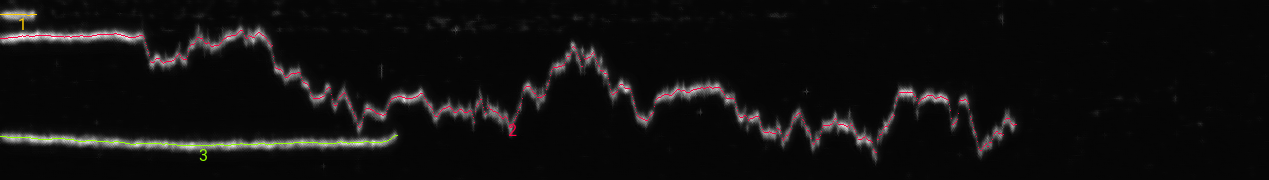

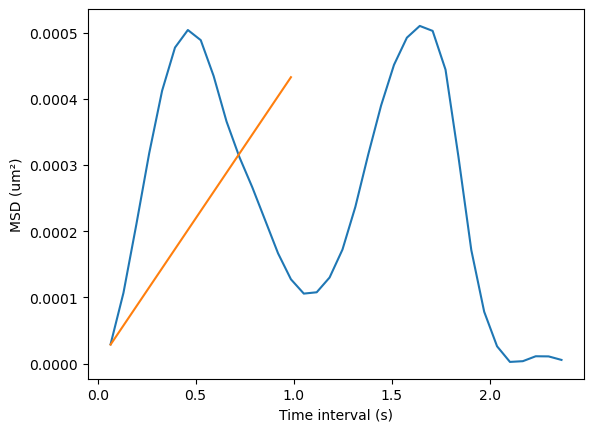

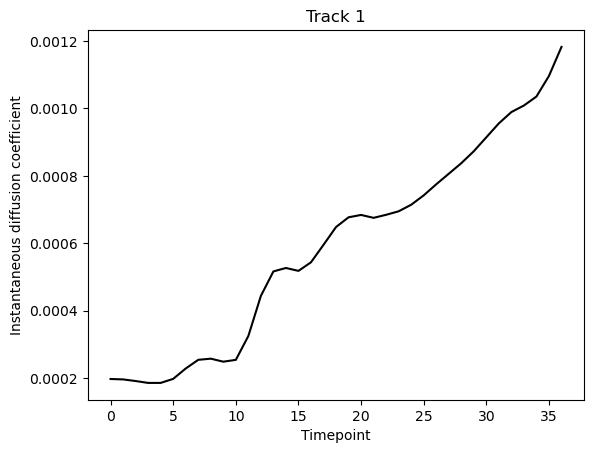

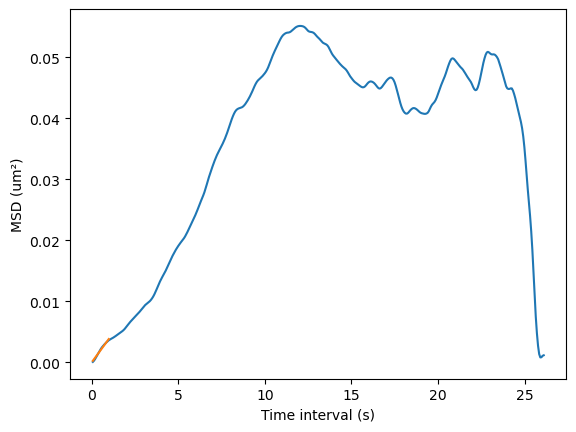

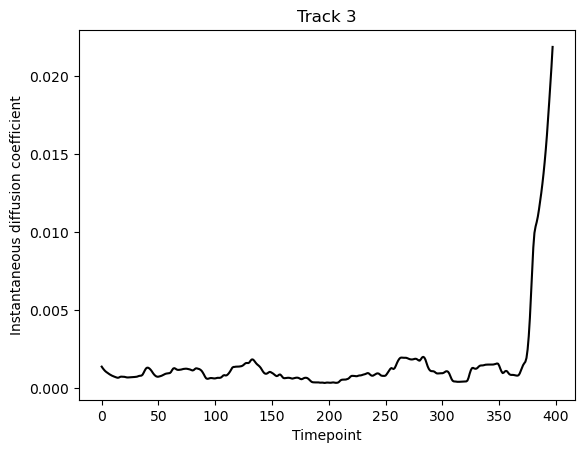

In [4]:
# Loading N2V model
if model_path is not None:
    model = N2V(config=None, name=model_name, basedir=model_path)
else:
    model = None

# Calculating diffusion coefficients
for name in os.listdir(input_path):
    if os.path.splitext(name)[1] == ".tif":
        print("Processing: ",name)
        tracks = process(input_path, output_path, name, channel, model)
            